#### Part A: Vector & Matrix Fundamentals

In [ ]:
import numpy as np
import pandas as pd

# Creating a sample dataset of Students and their Marks in different subjects
data = {
    'Student_A': [85, 90, 78, 92],  # [Maths, Physics, Chemistry, CS]
    'Student_B': [70, 65, 80, 75],
    'Student_C': [95, 88, 92, 90],
    'Student_D': [60, 55, 65, 70],
    'Student_E': [88, 92, 85, 89]
}

subjects = ['Mathematics', 'Physics', 'Chemistry', 'Computer_Science']

# Creating a DataFrame
df = pd.DataFrame(data, index=subjects).T
print("--- Student Performance Dataset ---")
print(df)

# Representing Student A and Student B as Vectors
v_A = np.array(df.loc['Student_A'])
v_B = np.array(df.loc['Student_B'])

print("\n--- Vector Representation ---")
print(f"Vector for Student A: {v_A}")
print(f"Vector for Student B: {v_B}")

In [2]:
# Function to compute Norm-1 and Norm-2 manually and using NumPy
def calculate_norms(vector, student_name):
    norm_1 = np.linalg.norm(vector, ord=1)  # L1 Norm (Sum of absolute values)
    norm_2 = np.linalg.norm(vector, ord=2)  # L2 Norm (Euclidean Distance / Magnitude)
    
    print(f"--- {student_name} ---")
    print(f"Vector: {vector}")
    print(f"Norm-1 (L1 Norm): {norm_1}")
    print(f"Norm-2 (L2 Norm): {norm_2:.4f}\n")

# Calculate for Student A and Student B
calculate_norms(v_A, 'Student_A')
calculate_norms(v_B, 'Student_B')

--- Student_A ---
Vector: [85 90 78 92]
Norm-1 (L1 Norm): 345.0
Norm-2 (L2 Norm): 172.8381

--- Student_B ---
Vector: [70 65 80 75]
Norm-1 (L1 Norm): 290.0
Norm-2 (L2 Norm): 145.4304



In [3]:
# Dot Product and Angle Calculation between Student A and Student B

# Calculate Dot Product
dot_product = np.dot(v_A, v_B)

# Calculate Norm-2 of both vectors
norm_A = np.linalg.norm(v_A, ord=2)
norm_B = np.linalg.norm(v_B, ord=2)

# Calculate Cosine of the Angle
cos_theta = dot_product / (norm_A * norm_B)

# Ensure cosine value stays strictly within [-1, 1] bounds due to floating point precision
cos_theta = np.clip(cos_theta, -1.0, 1.0)

# Calculate Angle in Radians and Degrees
angle_radians = np.arccos(cos_theta)
angle_degrees = np.degrees(angle_radians)

print("--- Dot Product & Angle Results ---")
print(f"Dot Product (Student_A . Student_B): {dot_product}")
print(f"Cosine Similarity (cos θ): {cos_theta:.4f}")
print(f"Angle in Radians: {angle_radians:.4f} rad")
print(f"Angle in Degrees: {angle_degrees:.2f}°")

--- Dot Product & Angle Results ---
Dot Product (Student_A . Student_B): 24940
Cosine Similarity (cos θ): 0.9922
Angle in Radians: 0.1249 rad
Angle in Degrees: 7.16°


In [4]:
# Cross Product (3D) & Vector Projection

# 1. Cross Product (Selecting first 3 subjects: Maths, Physics, Chemistry)
v_A_3d = v_A[:3]  # [Maths, Physics, Chemistry]
v_B_3d = v_B[:3]

cross_product = np.cross(v_A_3d, v_B_3d)

print("--- Cross Product (3D Selected Subjects) ---")
print(f"Student A (3D Vector): {v_A_3d}")
print(f"Student B (3D Vector): {v_B_3d}")
print(f"Cross Product Vector (v_A x v_B): {cross_product}")

# Verification of orthogonality (Dot product with cross product should be 0)
dot_verify = np.dot(cross_product, v_A_3d)
print(f"Verification Dot Product (Cross Product . v_A): {dot_verify}")


# 2. Vector Projection of Student A onto Student B (Full 4D vectors)
proj_A_onto_B = (np.dot(v_A, v_B) / np.dot(v_B, v_B)) * v_B

print("\n--- Vector Projection ---")
print(f"Projection Vector of Student A onto Student B:\n {np.round(proj_A_onto_B, 2)}")

--- Cross Product (3D Selected Subjects) ---
Student A (3D Vector): [85 90 78]
Student B (3D Vector): [70 65 80]
Cross Product Vector (v_A x v_B): [ 2130 -1340  -775]
Verification Dot Product (Cross Product . v_A): 0

--- Vector Projection ---
Projection Vector of Student A onto Student B:
 [82.54 76.65 94.34 88.44]


#### Part B: Matrix Operations


In [5]:
# Matrix Formation and Basic Operations

# 1. Form Matrix M (Students x Subjects) - Shape: (5, 4)
M = df.to_numpy()
print("--- Matrix M (5 Students x 4 Subjects) ---")
print(M)
print(f"Shape of Matrix M: {M.shape}\n")

# 2. Matrix Addition (Adding bonus marks matrix of same shape)
bonus_matrix = np.ones((5, 4)) * 5  # 5 bonus marks in all subjects
M_added = M + bonus_matrix
print("--- Matrix Addition (M + Bonus Marks Matrix) ---")
print(M_added)
print("\n")

# 3. Matrix Transpose (Subjects x Students) - Shape: (4, 5)
M_T = M.T
print("--- Transpose of Matrix M (M^T) ---")
print(M_T)
print(f"Shape of Matrix M^T: {M_T.shape}\n")

# 4. Matrix Multiplication (M x M^T) - Resulting Shape: (5, 5)
# Measures pair-wise dot products between all students
Gram_Matrix = np.dot(M, M_T)
print("--- Matrix Multiplication (M x M^T: Student Similarity / Gram Matrix) ---")
print(Gram_Matrix)
print(f"Shape of Gram Matrix: {Gram_Matrix.shape}")

--- Matrix M (5 Students x 4 Subjects) ---
[[85 90 78 92]
 [70 65 80 75]
 [95 88 92 90]
 [60 55 65 70]
 [88 92 85 89]]
Shape of Matrix M: (5, 4)

--- Matrix Addition (M + Bonus Marks Matrix) ---
[[ 90.  95.  83.  97.]
 [ 75.  70.  85.  80.]
 [100.  93.  97.  95.]
 [ 65.  60.  70.  75.]
 [ 93.  97.  90.  94.]]


--- Transpose of Matrix M (M^T) ---
[[85 70 95 60 88]
 [90 65 88 55 92]
 [78 80 92 65 85]
 [92 75 90 70 89]]
Shape of Matrix M^T: (4, 5)

--- Matrix Multiplication (M x M^T: Student Similarity / Gram Matrix) ---
[[29873 24940 31451 21560 30578]
 [24940 21150 26480 18225 25615]
 [31451 26480 33333 22820 32286]
 [21560 18225 22820 15750 22095]
 [30578 25615 32286 22095 31354]]
Shape of Gram Matrix: (5, 5)


#### Part C: Linear Transformations & Geometry


In [4]:
# Question 1: Mathematical Parameters for Line, Plane, and Hyperplane

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Dataset Setup
data = {
    'Student_A': [85, 90, 78, 92],
    'Student_B': [70, 65, 80, 75],
    'Student_C': [95, 88, 92, 90],
    'Student_D': [60, 55, 65, 70],
    'Student_E': [88, 92, 85, 89]
}
subjects = ['Mathematics', 'Physics', 'Chemistry', 'Computer_Science']
df = pd.DataFrame(data, index=subjects).T

# ---------------------------------------------------------
# A. Line (2D Space: Maths -> Physics)
# ---------------------------------------------------------
X_1d = df[['Mathematics']].values
y_1d = df['Physics'].values

model_line = LinearRegression().fit(X_1d, y_1d)
a1 = model_line.coef_[0]
b1 = model_line.intercept_

print("--- 1. Line Equation (2D Space) ---")
print(f"Physics = {a1:.2f} * (Mathematics) + {b1:.2f}\n")

# ---------------------------------------------------------
# B. Plane (3D Space: Maths, Physics -> Chemistry)
# ---------------------------------------------------------
X_2d = df[['Mathematics', 'Physics']].values
y_2d = df['Chemistry'].values

model_plane = LinearRegression().fit(X_2d, y_2d)
a2, b2 = model_plane.coef_
c2 = model_plane.intercept_

print("--- 2. Plane Equation (3D Space) ---")
print(f"Chemistry = {a2:.2f} * (Maths) + {b2:.2f} * (Physics) + {c2:.2f}\n")

# ---------------------------------------------------------
# C. Hyperplane (4D Space: Maths, Physics, Chemistry -> CS)
# ---------------------------------------------------------
X_3d = df[['Mathematics', 'Physics', 'Chemistry']].values
y_3d = df['Computer_Science'].values

model_hyper = LinearRegression().fit(X_3d, y_3d)
w = model_hyper.coef_
b3 = model_hyper.intercept_

print("--- 3. Hyperplane Equation (4D Space) ---")
print(f"{w[0]:.2f}*(Maths) + {w[1]:.2f}*(Physics) + {w[2]:.2f}*(Chemistry) - 1.00*(CS) + {b3:.2f} = 0")

--- 1. Line Equation (2D Space) ---
Physics = 1.12 * (Mathematics) + -11.27

--- 2. Plane Equation (3D Space) ---
Chemistry = 1.22 * (Maths) + -0.53 * (Physics) + 24.11

--- 3. Hyperplane Equation (4D Space) ---
0.45*(Maths) + 0.37*(Physics) + -0.31*(Chemistry) - 1.00*(CS) + 43.99 = 0


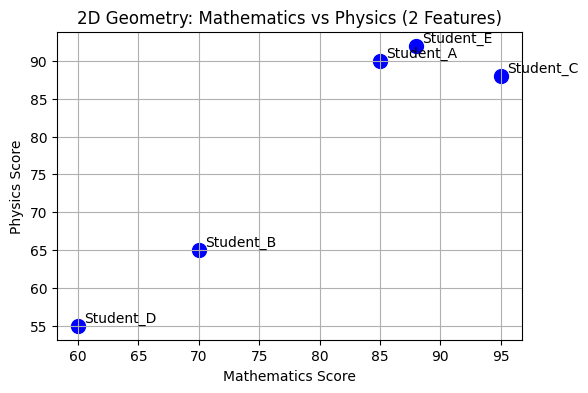

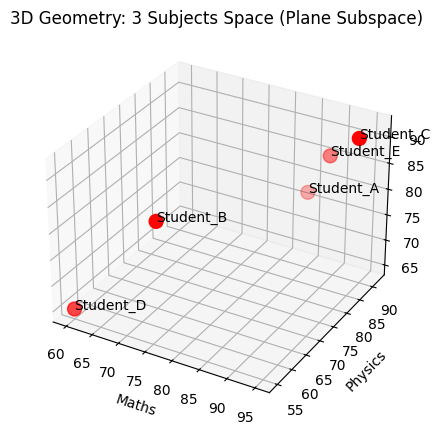

In [7]:
# Visualizing Geometry Across Dimensions (2D, 3D)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. 2D Geometry (Line representation: Maths vs Physics)
plt.figure(figsize=(6, 4))
plt.scatter(df['Mathematics'], df['Physics'], color='blue', s=100)

for idx, row in df.iterrows():
    plt.text(row['Mathematics'] + 0.5, row['Physics'] + 0.5, idx)

plt.title('2D Geometry: Mathematics vs Physics (2 Features)')
plt.xlabel('Mathematics Score')
plt.ylabel('Physics Score')
plt.grid(True)
plt.show()

# 2. 3D Geometry (Plane representation: Maths, Physics, Chemistry)
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

xs = df['Mathematics']
ys = df['Physics']
zs = df['Chemistry']

ax.scatter(xs, ys, zs, color='red', s=100)

for i in range(len(df)):
    ax.text(xs.iloc[i], ys.iloc[i], zs.iloc[i], df.index[i])

ax.set_title('3D Geometry: 3 Subjects Space (Plane Subspace)')
ax.set_xlabel('Maths')
ax.set_ylabel('Physics')
ax.set_zlabel('Chemistry')
plt.show()

#### Part D: Eigenvalues & Decomposition


In [8]:
# Covariance Matrix, Eigenvalues, and Eigenvectors

# 1. Calculate Covariance Matrix of the Dataset (Subjects x Subjects)
# Note: rowvar=False treats columns as variables (Subjects) and rows as observations (Students)
cov_matrix = np.cov(M, rowvar=False)

print("--- Covariance Matrix (4x4 Subjects) ---")
print(np.round(cov_matrix, 2))
print("\n")

# 2. Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort Eigenvalues and Eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("--- Eigenvalues ---")
for i, val in enumerate(eigenvalues):
    print(f"Eigenvalue λ_{i+1}: {val:.4f}")

print("\n--- Eigenvectors (Columns correspond to Eigenvalues) ---")
print(np.round(eigenvectors, 4))

# 3. Compute Explained Variance Ratio (%)
explained_variance_ratio = (eigenvalues / np.sum(eigenvalues)) * 100

print("\n--- Explained Variance Ratio (%) ---")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Component {i+1}: {ratio:.2f}% of total variance")

--- Covariance Matrix (4x4 Subjects) ---
[[203.3  228.   127.5  134.6 ]
 [228.   284.5  127.75 166.25]
 [127.5  127.75  99.5   72.75]
 [134.6  166.25  72.75  99.7 ]]


--- Eigenvalues ---
Eigenvalue λ_1: 641.6073
Eigenvalue λ_2: 40.6746
Eigenvalue λ_3: 3.8056
Eigenvalue λ_4: 0.9124

--- Eigenvectors (Columns correspond to Eigenvalues) ---
[[ 0.5567  0.2547 -0.6585 -0.4378]
 [ 0.6549 -0.4466  0.5524 -0.258 ]
 [ 0.3368  0.8001  0.3906  0.3065]
 [ 0.3844 -0.3092 -0.3297  0.8049]]

--- Explained Variance Ratio (%) ---
Component 1: 93.39% of total variance
Component 2: 5.92% of total variance
Component 3: 0.55% of total variance
Component 4: 0.13% of total variance
